# Advanced BDM Analysis

## Part of the open_dvm Toolbox

This tutorial builds on `05_bdm_decoding.ipynb` to explore advanced multivariate decoding techniques: temporal generalization, classifier/dimensionality-reduction comparisons, time-frequency decoding, and group-level permutation testing.

## Learning Objectives

After completing this tutorial, you will:

- **Assess temporal generalization** — Test whether a decoder trained at one time point generalizes to other time points (GAT)
- **Compare classifiers and PCA preprocessing** — See how classifier choice and dimensionality reduction affect decoding performance
- **Decode from time-frequency representations** — Identify which frequency bands carry decodable information
- **Establish group-level statistical significance** — Use permutation testing across subjects

**Prerequisites:** This tutorial assumes familiarity with the concepts introduced in `05_bdm_decoding.ipynb`.

## Overview

### Key Steps
1. **Generalization Across Time (GAT)**: Train at each time point, test at all others
2. **Classifier comparisons with PCA**: Compare LDA, SVM, and Gaussian Naive Bayes with/without PCA
3. **Time-frequency decoding**: Decode from time-frequency decomposed data
4. **Permutation testing**: Assess statistical significance of decoding across subjects

## Section 1: Setup and Configuration

### 1.1 Import Required Libraries

In [1]:
# Enable inline plotting and suppress warnings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from IPython.display import display

# Add open_dvm to path
sys.path.insert(0, '/Users/dvm/Documents/DvM')

# Import analysis tools
import warnings
warnings.filterwarnings('ignore')
# Suppress repeated classifier weights warning (expected for GNB and SVM with PCA)
warnings.filterwarnings('ignore', message='Classifier weights not available')

from open_dvm.analysis import BDM
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_bdm_timecourse

print("✓ All imports successful!")

✓ All imports successful!


### 1.2 Load Preprocessed Data with Eye-Tracking Quality Control

In [2]:
# ============================================
# Configuration: Change these for your data
# ============================================
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Subject number (1-7 in this dataset)
sj = 2

# Eye-tracking quality control
eye_dict = {
    'use_tracker': True,  # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),  # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,  # Threshold: 1 degree visual angle
    'viewing_dist': 70,  # Viewing distance (cm)
    'screen_res': (1920, 1080),  # Screen resolution (pixels)
    'screen_h': 29,  # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift correction window
}

# Load preprocessed data
df, epochs = FolderStructure().load_processed_epochs(
    sj, 'ses_01_main', 'main',eye_dict
)

print(f'✓ Subject {sj} data loaded')
print(f'  • {len(epochs)} trials')
print(f'  • {epochs.info["nchan"]} channels')
print(f'  • Sampling rate: {epochs.info["sfreq"]} Hz')

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2902 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
✓ Subject 2 data loaded
  • 2148 trials
  • 39 channels
  • Sampling rate: 512.0 Hz


---

## Section 2: Generalization Across Time (GAT)

**Question**: If we train a decoder at one time point, does it generalize to other time points? This reveals whether neural representations are stable or dynamic across the analysis window.

**Approach**: Train at each time point, test at all other time points. Result is a 2D matrix (train time × test time).

In [3]:
# Initialize BDM for GAT analysis
bdm_gat = BDM(
    sj=sj,
    epochs=epochs,
    df=df,
    to_decode='dist_img',   # Decode image identity
    baseline=(-0.2, 0),     # Baseline correction: -200 to 0 ms
    nr_folds=10,            # 10-fold cross-validation
    elec_oi='all',          # Use all electrodes
    data_type='raw',        # Time domain (not TF)
    downsample=64           # Downsample to 64 Hz for faster GAT computation
)

print(f"✓ BDM initialized for GAT analysis")

✓ BDM initialized for GAT analysis


In [4]:
# Run GAT analysis
output_gat, _ = bdm_gat.classify(
    cnds=dict(block_type=['localizer']),  # Select localizer trials
    window_oi=(-0.1, 0.4),  # Shrink window: -100 to 400 ms (500 ms total, was 700 ms)
    labels_oi='all',        # Use all distractor images
    f_name='localizer',     # Analysis identifier for saved output
    GAT=True,               # Enable generalization across time
)

print("✓ GAT decoding complete")
print(f"  • GAT matrix shape: {output_gat['localizer']['dec_scores'].shape}")

Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 10 out of 10 folds in run 1saving bdm scores
✓ GAT decoding complete
  • GAT matrix shape: (33, 33)


Times converted from seconds to milliseconds
not enough colors specified. Using default colors
Using a threshold of nan
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 0 clusters


/opt/anaconda3/envs/dvm/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/dvm/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/dvm/Documents/DvM/open_dvm/stats/stats_utils.py:477: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  t_obs, clusters, p_vals, H0 = mne.stats.permutation_cluster_1samp_test(
/Users/dvm/Documents/DvM/open_dvm/stats/stats_utils.py:477: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  t_obs, clusters, p_vals, H0 = mne.stats.permutation_cluster_1samp_test(


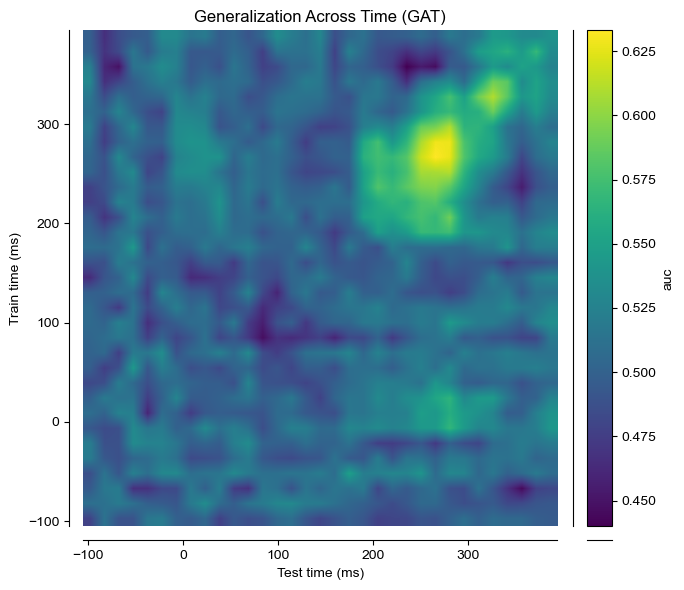

✓ GAT visualization complete


In [5]:
# Visualize GAT matrix
plt.figure(figsize=(7, 6))
plot_bdm_timecourse(
    output_gat,
    timecourse='2d_GAT',
    diverging_cmap=False,
    chance_level=0.5,
    mask_nonsig=False
)
plt.title('Generalization Across Time (GAT)')
plt.tight_layout()
display(plt.gcf())
plt.close()

print("✓ GAT visualization complete")

---

## Section 3: Classifier Comparisons with PCA

**Question**: How sensitive is decoding performance to classifier choice and dimensionality reduction?

**Approach**: Compare LDA, SVM, and Gaussian Naive Bayes with/without PCA preprocessing.


Decoding with LDA classifier...
   PCA: No PCA... Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 10 out of 10 folds in run 1saving bdm scores
AUC: 0.524
   PCA: 95%... Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per c

/Users/dvm/Documents/DvM/open_dvm/analysis/BDM.py:2899: UserWarning: Classifier weights are not computed when PCA is enabled; W/topography output will be all zeros
  warnings.warn(


Fold 10 out of 10 folds in run 1saving bdm scores
AUC: 0.504
   PCA: 99%... Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 1 out of 10 folds in run 1

/Users/dvm/Documents/DvM/open_dvm/analysis/BDM.py:2899: UserWarning: Classifier weights are not computed when PCA is enabled; W/topography output will be all zeros
  warnings.warn(


Fold 10 out of 10 folds in run 1saving bdm scores
AUC: 0.524
Times converted from seconds to milliseconds

Decoding with svm classifier...
   PCA: No PCA... Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 10 out of 10 folds in run 1saving bdm scores
AUC: 0.517
   PCA: 95%... Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used

...

saving bdm scores
AUC: 0.496
   PCA: 95%... Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 1 out of 10 folds in run 1

/Users/dvm/Documents/DvM/open_dvm/analysis/BDM.py:2899: UserWarning: Classifier weights are not computed when PCA is enabled; W/topography output will be all zeros
  warnings.warn(


Fold 10 out of 10 folds in run 1saving bdm scores
AUC: 0.496
   PCA: 99%... Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Fold 1 out of 10 folds in run 1

/Users/dvm/Documents/DvM/open_dvm/analysis/BDM.py:2899: UserWarning: Classifier weights are not computed when PCA is enabled; W/topography output will be all zeros
  warnings.warn(


Fold 10 out of 10 folds in run 1saving bdm scores
AUC: 0.504
Times converted from seconds to milliseconds


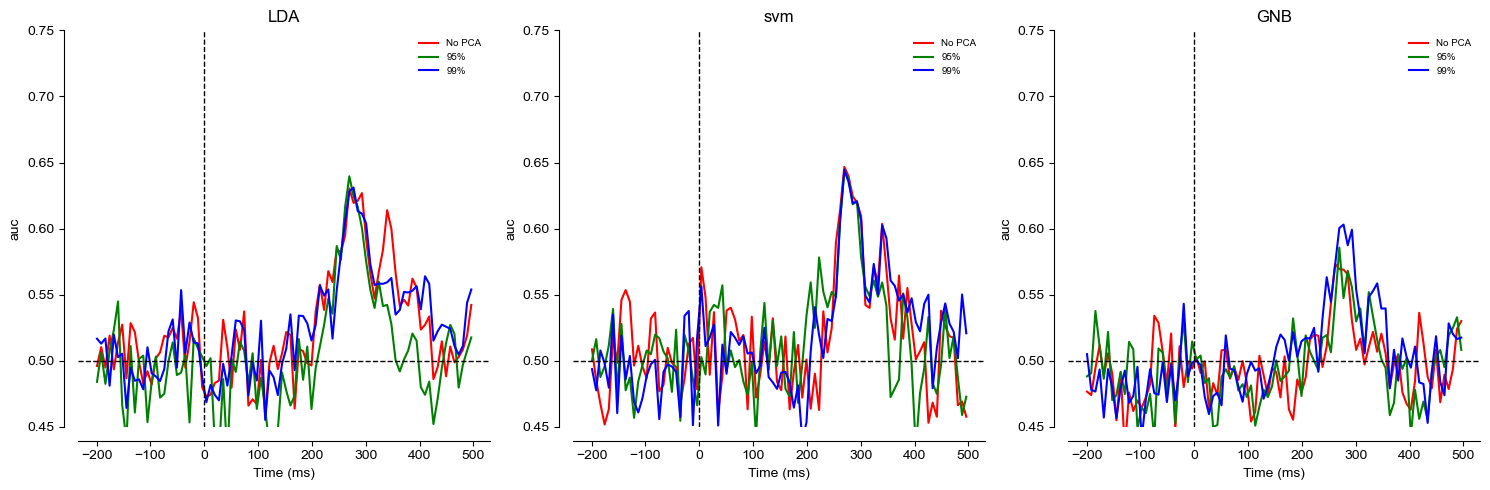


✓ Classifier and PCA comparison complete


In [6]:
# Classifier Comparisons with PCA
classifiers = ['LDA', 'svm', 'GNB']
pca_levels = [
    (0, 'across'),      # No PCA
    (0.95, 'across'),   # 95% variance
    (0.99, 'across')    # 99% variance
]
pca_labels = ['No PCA', '95%', '99%']
colors = ['red', 'green', 'blue']

# Initialize BDM once (will change classifier and pca_components in loops)
bdm_clf = BDM(
    sj=sj,
    epochs=epochs,
    df=df,
    to_decode='dist_img',   # Decode image identity
    baseline=(-0.2, 0),     # Baseline correction: -200 to 0 ms
    nr_folds=10,            # 10-fold cross-validation
    elec_oi='all',          # Use all electrodes
    data_type='raw',        # Time domain (not TF)
    downsample=128,         # Downsample to 128 Hz (reduce computational load)
    scale=True              # Standardize data before PCA
)

# Create 1x3 subplots for the three classifiers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for clf_idx, classifier in enumerate(classifiers):
    print(f'\nDecoding with {classifier} classifier...')

    # Update classifier
    bdm_clf.classifier = classifier

    # Collect outputs for all PCA levels into a single dict
    combined_output = {'info': None}

    for pca_idx, pca_comp in enumerate(pca_levels):
        # Update PCA setting
        bdm_clf.pca_components = pca_comp

        print(f'   PCA: {pca_labels[pca_idx]}', end='... ')

        # Run decoding (no GAT - just standard within-time)
        output, _ = bdm_clf.classify(
            cnds=dict(block_type=['localizer']),  # Select localizer trials
            window_oi=(-0.2, 0.5),                # Time window: -200 to 500 ms
            labels_oi='all',                      # Use all distractor images
            f_name='localizer',                   # Analysis identifier for saved output
            GAT=False,                             # Standard within-time decoding
        )

        print(f'AUC: {np.mean(output["localizer"]["dec_scores"]):.3f}')

        # Store in combined output dict
        combined_output[pca_labels[pca_idx]] = output['localizer']
        if combined_output['info'] is None:
            combined_output['info'] = output['info']

    # Plot all PCA levels for this classifier on its subplot
    plt.sca(axes[clf_idx])
    plot_bdm_timecourse(combined_output, timecourse='1d', colors=colors, 
                       chance_level=0.5, stats=False)
    axes[clf_idx].set_title(f'{classifier}')
    axes[clf_idx].set_ylim([0.45, 0.75])  # Enforce consistent y-axis limits

plt.tight_layout()
display(fig)
plt.close()

print("\n✓ Classifier and PCA comparison complete")

---

## Section 4: Time-Frequency Decoding

**Question**: Can we decode distractor image identity from time-frequency representations? Which frequencies are most informative?

**Approach**: Apply time-frequency decomposition (4–40 Hz) and run decoding in frequency domain. Visualize where decoding is strongest across the time-frequency plane.

In [7]:
# Initialize BDM with time-frequency decomposition
bdm_tfr = BDM(
    sj=sj,
    epochs=epochs,
    df=df,
    to_decode='dist_img',           # Decode distractor image identity
    baseline=(-0.2, 0),             # Baseline: -200 to 0 ms (percent change normalization)
    nr_folds=10,                    # 10-fold cross-validation
    elec_oi='all',                  # All electrodes
    data_type='tfr',                # TIME-FREQUENCY domain (not raw time domain)
    min_freq=4, max_freq=40,        # Frequency range: theta to low gamma (4-40 Hz)
    downsample=128                  # Downsample to 128 Hz
)

print("✓ BDM initialized for TFR analysis")

✓ BDM initialized for TFR analysis


In [8]:
# Run TFR decoding on localizer task
output_tfr, _ = bdm_tfr.classify(
    cnds=dict(block_type=['localizer']),  # Select localizer task
    window_oi=(-0.2, 0.5),                # Time window: -200 to 500 ms
    labels_oi='all',                      # All distractor images
    GAT=False,                            # Standard within-time decoding (no temporal generalization)
    excl_factor=dict(img_loc=[8]),        # Exclude no-show trials
    f_name='localizer'                    # Analysis identifier for saved output
)

print("✓ TFR decoding complete")
print(f"  • TFR shape: {output_tfr['localizer']['dec_scores'].shape}")

Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1650 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying percent change baseline for decoding
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 110

The difference between the highest and the lowest
number of observations per class is 15
Frequency 25 out of 25 in run 11saving bdm scores
✓ TFR decoding complete
  • TFR shape: (25, 90)



Visualizing time-frequency decoding results...
Times converted from seconds to milliseconds
not enough colors specified. Using default colors
Using a threshold of nan
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 0 clusters


/opt/anaconda3/envs/dvm/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/dvm/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/dvm/Documents/DvM/open_dvm/stats/stats_utils.py:477: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  t_obs, clusters, p_vals, H0 = mne.stats.permutation_cluster_1samp_test(
/Users/dvm/Documents/DvM/open_dvm/stats/stats_utils.py:477: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  t_obs, clusters, p_vals, H0 = mne.stats.permutation_cluster_1samp_test(


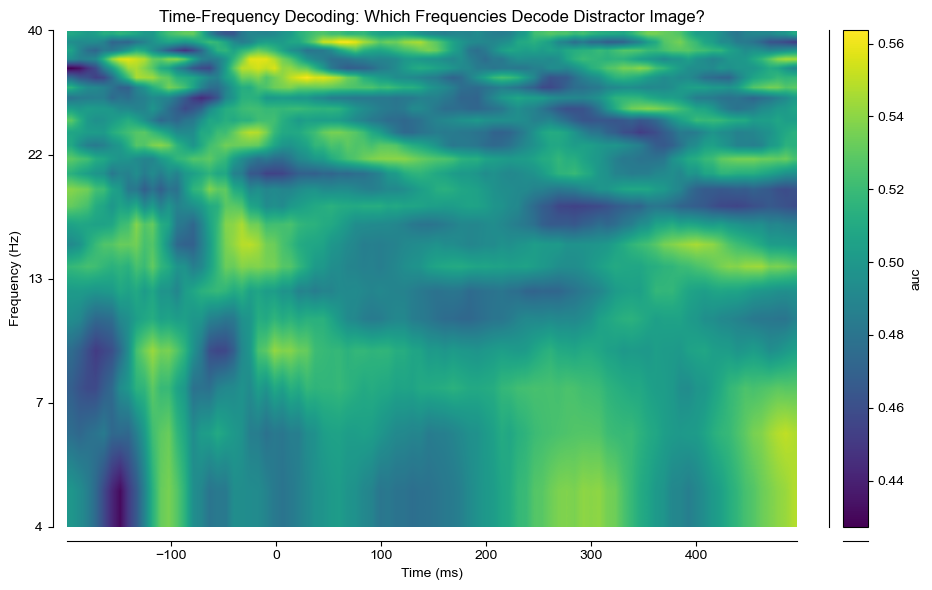

✓ Time-frequency decoding visualization complete


In [9]:
# Visualize time-frequency decoding performance
print('\nVisualizing time-frequency decoding results...')

plt.figure(figsize=(10, 6))
plot_bdm_timecourse(
    output_tfr,
    timecourse='2d_tfr',   # 2D time-frequency heatmap (time × frequency)
    diverging_cmap=False,  # Use sequential colormap (AUC scale)
    chance_level=0.5,      # Mark chance level
    mask_nonsig=False      # Show all time-frequency points
)
plt.title('Time-Frequency Decoding: Which Frequencies Decode Distractor Image?')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (ms)')
plt.tight_layout()
display(plt.gcf())
plt.close()

print('✓ Time-frequency decoding visualization complete')

---

## Section 5: Permutation Testing

**Question**: Is the observed decoding performance significantly above chance across subjects?

**Approach**: Run decoding across all subjects (1–7), then apply MNE's built-in permutation test to establish statistical significance.

In [10]:
# Run BDM decoding for all subjects (1-7)
print('\nDecoding distractor image across all subjects for permutation testing...')
for subject_id in range(1, 8):
    try:
        # Load data for this subject
        df_sj, epochs_sj = FolderStructure().load_processed_epochs(
            subject_id, 'ses_01_main', 'main', eye_dict
        )
        
        # Initialize BDM for this subject
        bdm_sj_temp = BDM(
            sj=subject_id,
            epochs=epochs_sj,
            df=df_sj,
            to_decode='dist_img',         # Decode distractor image identity
            baseline=(-0.2, 0),           # Baseline correction: -200 to 0 ms
            nr_folds=10,                  # 10-fold cross-validation
            elec_oi='all',                # All electrodes
            data_type='raw',              # Time domain (not TF)
            downsample=128                # Downsample to 128 Hz
        )

        # Run decoding on localizer task
        output_localizer, _ = bdm_sj_temp.classify(
            cnds=dict(block_type=['localizer']),  # Select localizer task
            window_oi=(-0.2, 0.5),                # Time window: -200 to 500 ms
            labels_oi='all',                      # All distractor images
            GAT=False,                            # Standard within-time decoding
            excl_factor=dict(img_loc=[8]),        # Exclude no-show trials
            f_name='localizer'                    # Analysis identifier for saved output
        )
        
        print(f'  ✓ Subject {subject_id} complete')
    except Exception as e:
        print(f'  ✗ Subject {subject_id} failed: {str(e)}')

print('\n✓ All subjects processed')


Decoding distractor image across all subjects for permutation testing...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_01_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2891 matching events found
No baseline correction applied
0 projection items activated
42 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
Automatically excluding block_type=['main'] (not specified in cnds parameter)
Dropped 1903 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Applying baseline correction (mode: mean)
downsampling data

You are decoding localizer. The nr of trials used for
folding is set to 230

The difference between the highest and the lowest
number of observations per class 

In [11]:
# Load aggregated decoding results across all subjects
print('\nLoading decoded data...')
bdm_perm_data = FolderStructure().read_bdm(
    bdm_folder_path=['dist_img', 'all_elecs'],  # Feature space and channels
    bdm_name='localizer',                        # From localizer task
    sjs='all'                                    # All subjects
)
print('✓ Data loaded')


Loading decoded data...
✓ Data loaded



Visualizing permutation test results...
Times converted from seconds to milliseconds
Using a threshold of 2.446912
stat_fun(H1): min=-3.1155872718350333 max=7.950113019298303
Running initial clustering …
Found 7 clusters


  0%|          | Permuting (exact test) : 0/63 [00:00<?,       ?it/s]

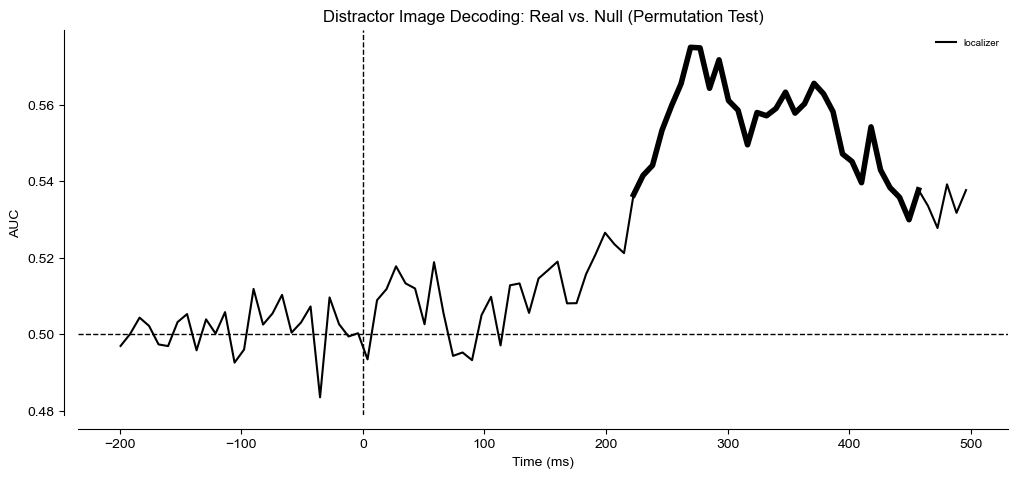

✓ Permutation testing complete


In [12]:
# Visualize decoding performance with permutation-based statistics
print('\nVisualizing permutation test results...')

plt.figure(figsize=(12, 5))
plot_bdm_timecourse(
    bdm_perm_data, 
    timecourse='1d',      # 1D timecourse (not GAT)
    colors=['black'],     # Single color for observed data (as list)
    stats='perm'          # Show permutation-based significance (shaded null distribution)
)
plt.title('Distractor Image Decoding: Real vs. Null (Permutation Test)')
plt.ylabel('AUC')
plt.xlabel('Time (ms)')
display(plt.gcf())
plt.close()

print('✓ Permutation testing complete')

---

## Section 6: Summary and Next Steps

You've explored advanced BDM techniques in a natural progression:

1. ✅ **GAT**: Temporal stability and generalization of neural representations (single-subject)
2. ✅ **Classifiers + PCA**: Trade-offs in model complexity and performance (single-subject)
3. ✅ **Time-Frequency**: Which frequencies best decode image identity (single-subject)
4. ✅ **Permutation Testing**: Statistical significance of decoding results across subjects

### Next Steps
- See `07_ctf_analysis.ipynb` for spatial channel tuning functions (inverted encoding model), a complementary approach to studying how continuous stimulus features are represented in EEG activity.